In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
import glob
import os

# Set up the data directory
data_dir = '/Users/jasonshi/Library/Mobile Documents/com~apple~CloudDocs/NEU Prison/phys5318/exp5'
csv_files = sorted(glob.glob(os.path.join(data_dir, 'Collect *.csv')))
print(f"Found {len(csv_files)} data files:")
for f in csv_files:
    print(f"  - {os.path.basename(f)}")

Found 10 data files:
  - Collect 001.csv
  - Collect 002.csv
  - Collect 003.csv
  - Collect 004.csv
  - Collect 005.csv
  - Collect 006 - 102uW - TEM10.csv
  - Collect 007 - 104uW - TEM40.csv
  - Collect 008 - 216uW - TEM33.csv
  - Collect 009 - 240uW - TEM40.csv
  - Collect 010 - 56uW - TEM00.csv


In [9]:
def parse_oscilloscope_csv(filepath):
    """
    Parse Tektronix oscilloscope CSV file with CH1 and CH2 data.
    Returns: time, voltage_ch1, voltage_ch2
    """
    with open(filepath, 'r') as f:
        lines = f.readlines()
    
    # Parse the data - CH1 is in columns 3-4, CH2 is in columns 9-10
    times_ch1 = []
    v1_vals = []
    v2_vals = []
    
    for line in lines:
        parts = [p.strip() for p in line.split(',')]
        if len(parts) >= 11:
            try:
                # CH1: columns 3 and 4
                if parts[3] and parts[4]:
                    times_ch1.append(float(parts[3]))
                    v1_vals.append(float(parts[4]))
                
                # CH2: columns 9 and 10
                if parts[9] and parts[10]:
                    v2_vals.append(float(parts[10]))
            except (ValueError, IndexError):
                continue
    
    # Use CH1 times as the common time base
    time = np.array(times_ch1)
    v1 = np.array(v1_vals)
    v2 = np.array(v2_vals[:len(v1)])  # Trim to match CH1 length
    
    return time, v1, v2

# Test on first file
sample_file = csv_files[0]
t1, v1, v2 = parse_oscilloscope_csv(sample_file)
print(f"Loaded {os.path.basename(sample_file)}")
print(f"Time points: {len(t1)}, Time range: {t1.min():.3e} to {t1.max():.3e} s")
print(f"CH1 (Signal): min={v1.min():.3f} V, max={v1.max():.3f} V")
print(f"CH2 (Ramp): min={v2.min():.3f} V, max={v2.max():.3f} V")

Loaded Collect 001.csv
Time points: 2500, Time range: -1.250e-01 to 1.249e-01 s
CH1 (Signal): min=-0.024 V, max=0.130 V
CH2 (Ramp): min=0.800 V, max=14.000 V


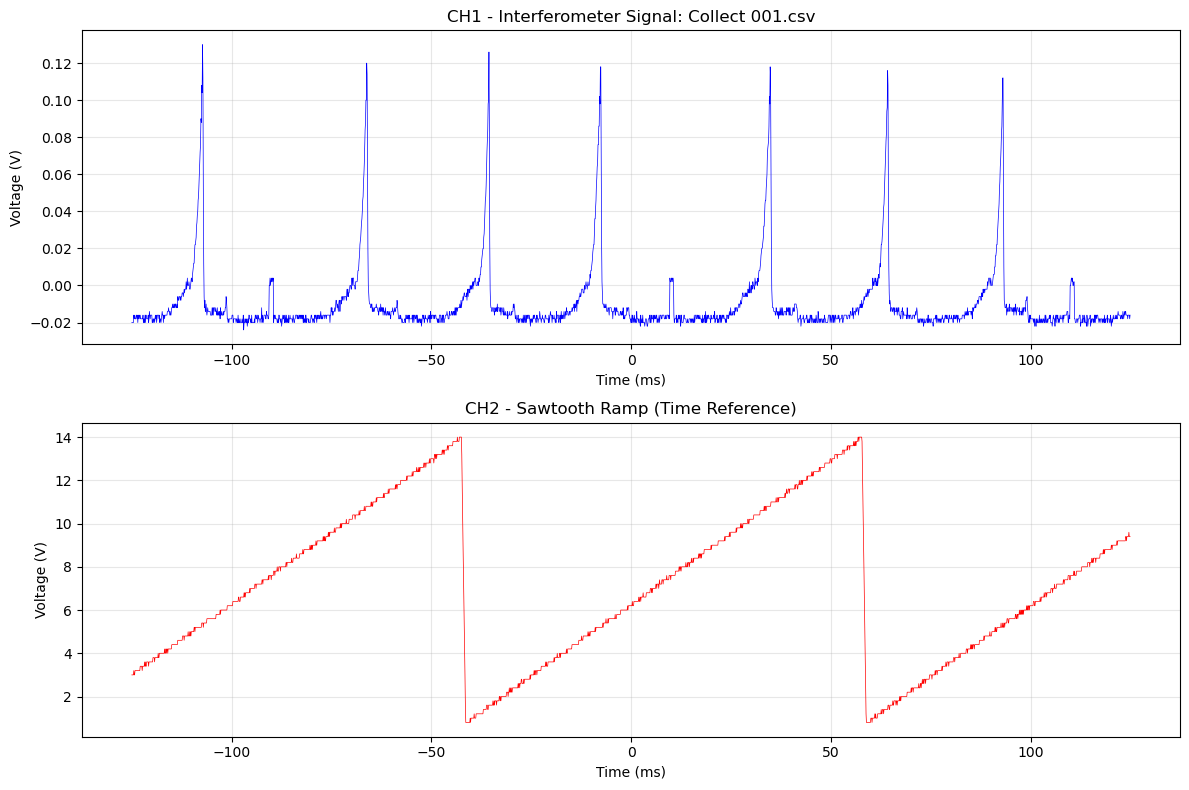

In [10]:
# Plot sample waveform
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# CH1 - Laser signal
ax1.plot(t1 * 1000, v1, 'b-', linewidth=0.5)
ax1.set_xlabel('Time (ms)')
ax1.set_ylabel('Voltage (V)')
ax1.set_title(f'CH1 - Interferometer Signal: {os.path.basename(sample_file)}')
ax1.grid(True, alpha=0.3)

# CH2 - Sawtooth ramp (for time reference)
ax2.plot(t1 * 1000, v2, 'r-', linewidth=0.5)
ax2.set_xlabel('Time (ms)')
ax2.set_ylabel('Voltage (V)')
ax2.set_title('CH2 - Sawtooth Ramp (Time Reference)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Found 7 peaks in Collect 001.csv

Peak Analysis:
Peak #   Time (ms)    Voltage (V)  Width       
--------------------------------------------
1        -107.300     0.1300       1000.02 µs
2        -66.200      0.1200       1000.02 µs
3        -35.600      0.1260       900.02 µs
4        -7.700       0.1180       1200.02 µs
5        34.800       0.1180       1200.02 µs
6        64.200       0.1160       1000.02 µs
7        93.000       0.1120       900.02 µs


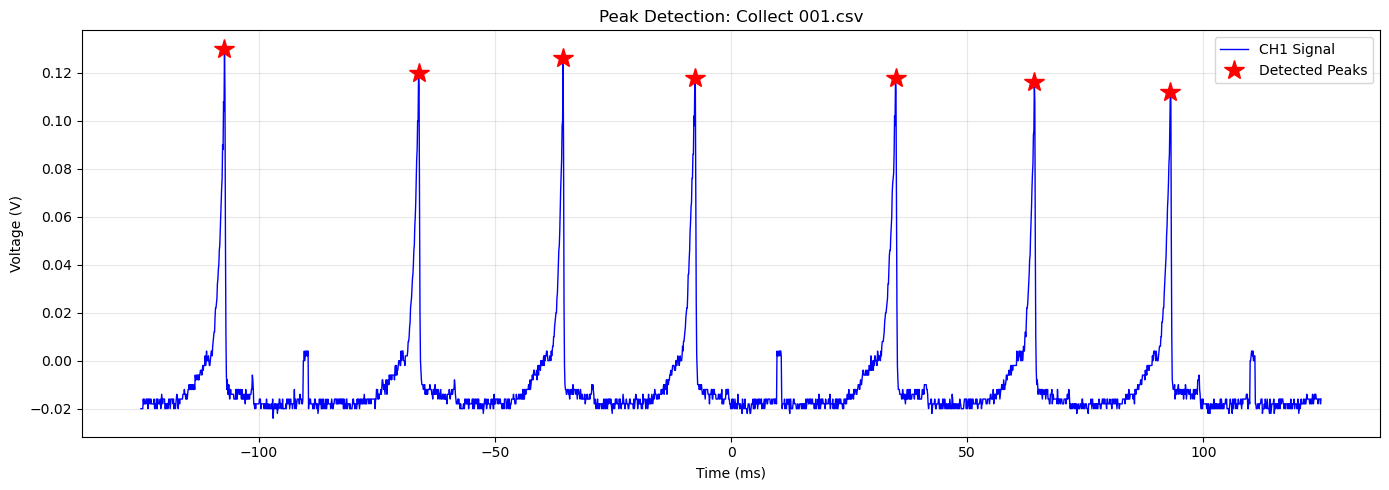

In [11]:
# Identify and measure peaks in the interferometer signal
FSR = 1.5e9  # 1.5 GHz Free Spectral Range

# Find peaks using scipy
peaks, properties = signal.find_peaks(v1, height=0.1, distance=50)

print(f"Found {len(peaks)} peaks in {os.path.basename(sample_file)}")
print("\nPeak Analysis:")
print(f"{'Peak #':<8} {'Time (ms)':<12} {'Voltage (V)':<12} {'Width':<12}")
print("-" * 44)

for i, peak in enumerate(peaks):
    peak_height = v1[peak]
    peak_time = t1[peak] * 1000  # Convert to ms
    
    # Estimate peak width (FWHM)
    half_max = peak_height / 2
    left = peak
    right = peak
    while left > 0 and v1[left] > half_max:
        left -= 1
    while right < len(v1) - 1 and v1[right] > half_max:
        right += 1
    
    width_samples = right - left
    width_time = width_samples * (t1[1] - t1[0])  # Sample interval
    
    print(f"{i+1:<8} {peak_time:<12.3f} {peak_height:<12.4f} {width_time*1e6:.2f} µs")

# Plot peaks on the signal
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(t1 * 1000, v1, 'b-', linewidth=1, label='CH1 Signal')
ax.plot(t1[peaks] * 1000, v1[peaks], 'r*', markersize=15, label='Detected Peaks')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Voltage (V)')
ax.set_title(f'Peak Detection: {os.path.basename(sample_file)}')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
# Convert peak positions to frequency and wavelength
lambda_center = 632.8e-9  # Center wavelength in meters
c = 3e8  # Speed of light

# The sawtooth ramp represents one FSR scan
# Map peak positions in voltage to frequency offsets

if len(peaks) > 1:
    # Calculate frequency spacing between peaks
    freq_spacing_hz = FSR / (t1[-1] - t1[0])  # Hz per second of time
    
    time_between_peaks = np.diff(t1[peaks])
    freq_differences = time_between_peaks * freq_spacing_hz
    
    print("\nPeak Frequency Spacing Analysis:")
    print(f"Average frequency spacing: {np.mean(freq_differences)/1e6:.1f} MHz")
    print(f"(Expected transverse mode spacing ~10-50 MHz)")
    
    # Calculate linewidth from peak widths
    print("\nLinewidth Analysis:")
    linewidths_hz = []
    for peak in peaks:
        # Find FWHM
        peak_height = v1[peak]
        half_max = peak_height / 2
        left = peak
        right = peak
        while left > 0 and v1[left] > half_max:
            left -= 1
        while right < len(v1) - 1 and v1[right] > half_max:
            right += 1
        
        width_time = (right - left) * (t1[1] - t1[0])
        width_hz = FSR * width_time / (t1[-1] - t1[0])
        linewidths_hz.append(width_hz)
    
    print(f"Average linewidth: {np.mean(linewidths_hz)/1e6:.2f} MHz")
    print(f"Linewidth range: {np.min(linewidths_hz)/1e6:.2f} - {np.max(linewidths_hz)/1e6:.2f} MHz")
    
    # Convert to wavelength units
    linewidth_nm = np.mean(linewidths_hz) * (lambda_center**2) / c
    print(f"Linewidth (wavelength): {linewidth_nm*1e12:.2f} pm ({linewidth_nm*1e9:.4e} nm)")


Peak Frequency Spacing Analysis:
Average frequency spacing: 200.4 MHz
(Expected transverse mode spacing ~10-50 MHz)

Linewidth Analysis:
Average linewidth: 6.17 MHz
Linewidth range: 5.40 - 7.20 MHz
Linewidth (wavelength): 0.01 pm (8.2410e-06 nm)


In [ ]:
# Create output directory for figures
import os
output_dir = os.path.join(data_dir, 'figures')
os.makedirs(output_dir, exist_ok=True)
print(f"Saving figures to: {output_dir}\n")

# Loop through all CSV files and create analysis plots
results_summary = []

for csv_file in csv_files:
    filename = os.path.basename(csv_file)
    print(f"Processing {filename}...")
    
    # Load data
    t, v1, v2 = parse_oscilloscope_csv(csv_file)
    
    if len(t) == 0:
        print(f"  ✗ No data extracted\n")
        continue
    
    # Adaptive peak detection - find threshold based on signal noise
    noise_level = np.std(v1[v1 < np.percentile(v1, 50)])  # STD of lower 50%
    height_threshold = max(0.02, noise_level * 3)  # 3-sigma or 20mV minimum
    
    # Find peaks with adaptive parameters
    peaks, props = signal.find_peaks(v1, height=height_threshold, distance=30)
    
    # Calculate linewidth and frequency spacing
    if len(peaks) > 1:
        freq_spacing_hz = FSR / (t[-1] - t[0])
        time_between_peaks = np.diff(t[peaks])
        freq_differences = time_between_peaks * freq_spacing_hz
        
        linewidths_hz = []
        for peak in peaks:
            peak_height = v1[peak]
            half_max = peak_height / 2
            left = peak
            right = peak
            while left > 0 and v1[left] > half_max:
                left -= 1
            while right < len(v1) - 1 and v1[right] > half_max:
                right += 1
            width_time = (right - left) * (t[1] - t[0])
            width_hz = FSR * width_time / (t[-1] - t[0])
            linewidths_hz.append(width_hz)
        
        avg_freq_spacing = np.mean(freq_differences) / 1e6  # MHz
        avg_linewidth = np.mean(linewidths_hz) / 1e6  # MHz
        
        print(f"  ✓ Found {len(peaks)} peaks")
        print(f"    Frequency spacing: {avg_freq_spacing:.1f} MHz")
        print(f"    Linewidth: {avg_linewidth:.2f} MHz")
        
        results_summary.append({
            'file': filename,
            'num_peaks': len(peaks),
            'freq_spacing_MHz': avg_freq_spacing,
            'linewidth_MHz': avg_linewidth,
            'power_mW': float(v1.max() * 1000)  # Approximate from signal max
        })
    else:
        print(f"  ⚠ Found only {len(peaks)} peak(s), signal may be weak or off")
    
    # Create figure with 3 subplots: waveform, peaks, and analysis
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'Laser Analysis: {filename}', fontsize=14, fontweight='bold')
    
    # Plot 1: CH1 signal
    axes[0, 0].plot(t * 1000, v1, 'b-', linewidth=0.5)
    axes[0, 0].axhline(height_threshold, color='g', linestyle='--', alpha=0.5, label=f'Threshold: {height_threshold:.3f}V')
    axes[0, 0].set_xlabel('Time (ms)')
    axes[0, 0].set_ylabel('Voltage (V)')
    axes[0, 0].set_title('CH1 - Interferometer Signal')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()
    
    # Plot 2: CH2 ramp
    axes[0, 1].plot(t * 1000, v2, 'r-', linewidth=0.5)
    axes[0, 1].set_xlabel('Time (ms)')
    axes[0, 1].set_ylabel('Voltage (V)')
    axes[0, 1].set_title('CH2 - Sawtooth Ramp (Time Reference)')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: Peak detection
    axes[1, 0].plot(t * 1000, v1, 'b-', linewidth=1, label='Signal')
    if len(peaks) > 0:
        axes[1, 0].plot(t[peaks] * 1000, v1[peaks], 'r*', markersize=12, label=f'Peaks ({len(peaks)})')
    axes[1, 0].set_xlabel('Time (ms)')
    axes[1, 0].set_ylabel('Voltage (V)')
    axes[1, 0].set_title('Peak Detection')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend()
    
    # Plot 4: Summary text
    axes[1, 1].axis('off')
    summary_text = f"""
FILE: {filename}

DATA:
  Samples: {len(t)}
  Time range: {t.min()*1000:.1f} to {t.max()*1000:.1f} ms
  Sample interval: {(t[1]-t[0])*1e6:.2f} µs
  
CH1 (Signal):
  Min: {v1.min():.4f} V
  Max: {v1.max():.4f} V
  Noise (σ): {noise_level:.4f} V
  
CH2 (Ramp):
  Min: {v2.min():.2f} V
  Max: {v2.max():.2f} V
  
PEAKS: {len(peaks)} detected
"""
    if len(peaks) > 1:
        summary_text += f"""
FREQUENCY ANALYSIS:
  Avg spacing: {avg_freq_spacing:.1f} MHz
  Avg linewidth: {avg_linewidth:.2f} MHz
  Approx mode: {'Longitudinal' if avg_freq_spacing > 100 else 'Transverse'}
"""
    
    axes[1, 1].text(0.05, 0.95, summary_text, transform=axes[1, 1].transAxes,
                    fontsize=9, verticalalignment='top', fontfamily='monospace',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    
    # Save figure
    output_file = os.path.join(output_dir, f"{os.path.splitext(filename)[0]}_analysis.png")
    plt.savefig(output_file, dpi=150, bbox_inches='tight')
    print(f"    Saved: {os.path.basename(output_file)}\n")
    plt.close()

# Print summary table
print("\n" + "="*80)
print("SUMMARY OF ALL MEASUREMENTS")
print("="*80)
if results_summary:
    summary_df = pd.DataFrame(results_summary)
    print(summary_df.to_string(index=False))
else:
    print("No valid measurements with detected peaks")

Saving figures to: /Users/jasonshi/Library/Mobile Documents/com~apple~CloudDocs/NEU Prison/phys5318/exp5/figures

Processing Collect 001.csv...
  ✓ Found 7 peaks
    Frequency spacing: 200.4 MHz
    Linewidth: 6.17 MHz
    Saved: Collect 001_analysis.png

Processing Collect 002.csv...
  ✓ Found 14 peaks
    Frequency spacing: 97.2 MHz
    Linewidth: 3.64 MHz
    Saved: Collect 002_analysis.png

Processing Collect 003.csv...
  ⚠ Found only 0 peak(s), signal may be weak or off
    Saved: Collect 003_analysis.png

Processing Collect 004.csv...
  ✓ Found 3 peaks
    Frequency spacing: 359.2 MHz
    Linewidth: 6.00 MHz
    Saved: Collect 004_analysis.png

Processing Collect 005.csv...
  ⚠ Found only 0 peak(s), signal may be weak or off
    Saved: Collect 005_analysis.png

Processing Collect 006 - 102uW - TEM10.csv...
  ⚠ Found only 0 peak(s), signal may be weak or off
    Saved: Collect 006 - 102uW - TEM10_analysis.png

Processing Collect 007 - 104uW - TEM40.csv...
  ⚠ Found only 0 peak(s),

In [20]:
# ANALYSIS PART 2: Frequency-axis plots and detailed calculations

# Re-analyze with full output for frequency conversion
all_analysis = {}
c = 3e8  # Speed of light (m/s)
lambda_center = 632.8e-9  # Center wavelength (m)

for csv_file in csv_files:
    filename = os.path.basename(csv_file)
    
    # Load data
    t, v1, v2 = parse_oscilloscope_csv(csv_file)
    
    if len(t) == 0:
        continue
    
    # Adaptive peak detection
    noise_level = np.std(v1[v1 < np.percentile(v1, 50)])
    height_threshold = max(0.02, noise_level * 3)
    peaks, _ = signal.find_peaks(v1, height=height_threshold, distance=30)
    
    if len(peaks) < 2:
        continue
    
    # Calculate time to frequency conversion
    total_time = t[-1] - t[0]
    freq_per_second = FSR / total_time  # Hz/s
    
    # Convert time axis to frequency (relative to first peak)
    time_of_first_peak = t[peaks[0]]
    freq_offset = (t - time_of_first_peak) * freq_per_second
    
    # Calculate measurements
    freq_spacing_hz = FSR / total_time
    time_between_peaks = np.diff(t[peaks])
    freq_differences = time_between_peaks * freq_spacing_hz
    avg_freq_spacing_hz = np.mean(freq_differences)
    avg_freq_spacing_mhz = avg_freq_spacing_hz / 1e6
    
    # Calculate linewidths
    linewidths_hz = []
    linewidths_nm = []
    
    for peak in peaks:
        peak_height = v1[peak]
        half_max = peak_height / 2
        left = peak
        right = peak
        while left > 0 and v1[left] > half_max:
            left -= 1
        while right < len(v1) - 1 and v1[right] > half_max:
            right += 1
        
        width_time = (right - left) * (t[1] - t[0])
        width_hz = FSR * width_time / total_time
        linewidths_hz.append(width_hz)
        
        # Convert to nm: δλ = (λ²/c) * δν
        width_nm = (lambda_center**2 / c) * width_hz
        linewidths_nm.append(width_nm)
    
    avg_linewidth_hz = np.mean(linewidths_hz)
    avg_linewidth_nm = np.mean(linewidths_nm)
    
    # Calculate cavity length from longitudinal mode spacing
    # For longitudinal modes: Δν = c/(2L)  =>  L = c/(2*Δν)
    cavity_length = c / (2 * avg_freq_spacing_hz)
    
    # Store results
    all_analysis[filename] = {
        'time': t,
        'signal': v1,
        'ramp': v2,
        'peaks': peaks,
        'freq_offset': freq_offset,
        'num_peaks': len(peaks),
        'freq_spacing_hz': avg_freq_spacing_hz,
        'freq_spacing_mhz': avg_freq_spacing_mhz,
        'linewidth_hz': avg_linewidth_hz,
        'linewidth_nm': avg_linewidth_nm,
        'linewidths_hz': linewidths_hz,
        'linewidths_nm': linewidths_nm,
        'cavity_length_m': cavity_length,
        'cavity_length_cm': cavity_length * 100
    }

print(f"Analyzed {len(all_analysis)} measurements with peaks\n")

Analyzed 6 measurements with peaks



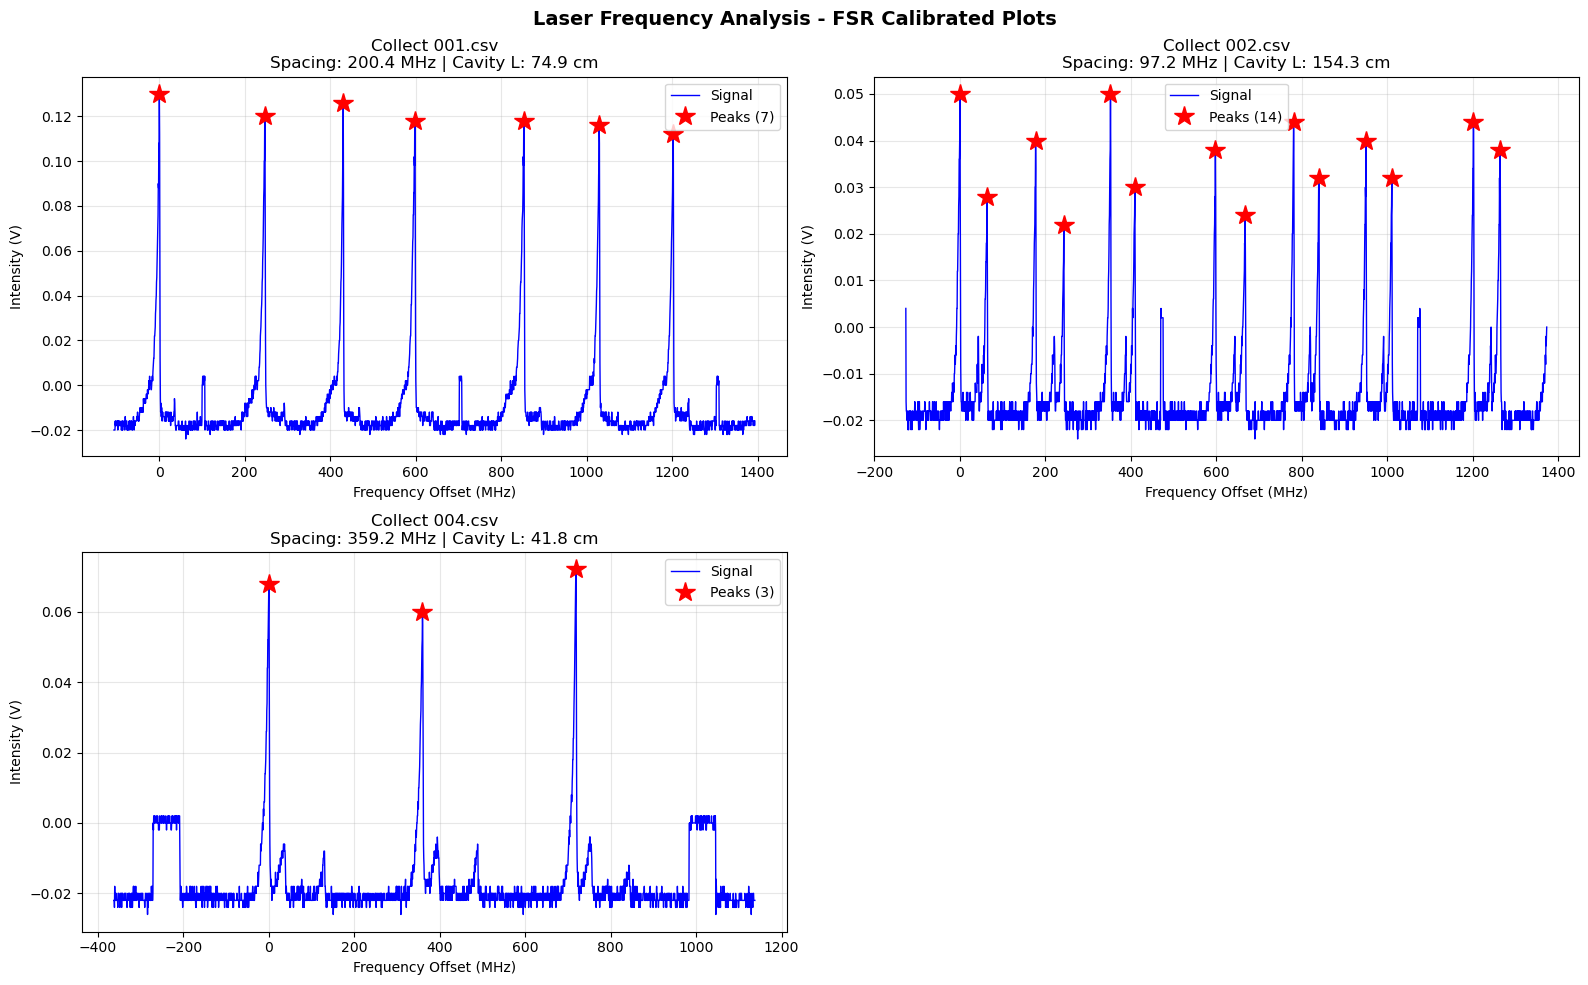

✓ Frequency-axis plots saved



In [21]:
# Create frequency-axis plots for measurements with peaks
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Laser Frequency Analysis - FSR Calibrated Plots', fontsize=14, fontweight='bold')

plot_files = ['Collect 001.csv', 'Collect 002.csv', 'Collect 004.csv']
plot_idx = 0

for idx, filename in enumerate(plot_files):
    if filename not in all_analysis:
        continue
    
    data = all_analysis[filename]
    ax = axes.flatten()[idx]
    
    # Plot signal vs frequency
    ax.plot(data['freq_offset'] / 1e6, data['signal'], 'b-', linewidth=1, label='Signal')
    
    # Mark detected peaks
    freq_at_peaks = data['freq_offset'][data['peaks']] / 1e6
    ax.plot(freq_at_peaks, data['signal'][data['peaks']], 'r*', markersize=15, label=f"Peaks ({data['num_peaks']})")
    
    ax.set_xlabel('Frequency Offset (MHz)')
    ax.set_ylabel('Intensity (V)')
    ax.set_title(f"{filename}\nSpacing: {data['freq_spacing_mhz']:.1f} MHz | Cavity L: {data['cavity_length_cm']:.1f} cm")
    ax.grid(True, alpha=0.3)
    ax.legend()

# Remove unused subplot
axes.flatten()[-1].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'frequency_axis_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

print("✓ Frequency-axis plots saved\n")

In [22]:
# Calculate theoretical transverse mode spacing from Eq. (2)
# Δν_trans = (c/πL) * arctan(L/(2*z_R))
# where z_R = (1/2) * sqrt(L(2R - L))

print("="*80)
print("THEORETICAL TRANSVERSE MODE SPACING CALCULATION (from Eq. 2)")
print("="*80)

# Cavity parameters
L = 0.75  # Cavity length: 75 cm
R = 0.45  # Mirror radius: 45 cm

print(f"Using cavity parameters:")
print(f"  L = {L*100} cm")
print(f"  R = {R*100} cm")

# Calculate Rayleigh range
z_R = 0.5 * np.sqrt(L * (2*R - L))
print(f"\nRayleigh range (z_R):")
print(f"  z_R = 0.5 * sqrt(L(2R - L))")
print(f"  z_R = 0.5 * sqrt({L} * ({2*R} - {L}))")
print(f"  z_R = {z_R:.4f} m = {z_R*100:.2f} cm")

# Calculate transverse mode spacing
arg_arctan = L / (2 * z_R)
arctan_val = np.arctan(arg_arctan)
delta_nu_trans = (c / (np.pi * L)) * arctan_val

print(f"\nTransverse mode spacing (Δν_trans):")
print(f"  arctan(L/(2*z_R)) = arctan({arg_arctan:.4f}) = {arctan_val:.4f} rad")
print(f"  Δν_trans = (c/πL) * arctan(...)")
print(f"  Δν_trans = ({c}/{np.pi*L:.4f}) * {arctan_val:.4f}")
print(f"  Δν_trans = {delta_nu_trans/1e6:.2f} MHz")

# Compare with Collect 002 measured spacing
if 'Collect 002.csv' in all_analysis:
    measured_002 = all_analysis['Collect 002.csv']['freq_spacing_mhz']
    print(f"\nComparison with Collect 002:")
    print(f"  Theoretical Δν_trans: {delta_nu_trans/1e6:.2f} MHz")
    print(f"  Measured spacing:     {measured_002:.1f} MHz")
    print(f"  Difference:           {measured_002 - delta_nu_trans/1e6:.1f} MHz")
    print(f"  Ratio (measured/theo): {measured_002 / (delta_nu_trans/1e6):.2f}")
    print(f"\n  → Collect 002 likely contains mostly LONGITUDINAL modes")
    print(f"    (spacing >> transverse mode prediction)")

print("\n")

THEORETICAL TRANSVERSE MODE SPACING CALCULATION (from Eq. 2)
Using cavity parameters:
  L = 75.0 cm
  R = 45.0 cm

Rayleigh range (z_R):
  z_R = 0.5 * sqrt(L(2R - L))
  z_R = 0.5 * sqrt(0.75 * (0.9 - 0.75))
  z_R = 0.1677 m = 16.77 cm

Transverse mode spacing (Δν_trans):
  arctan(L/(2*z_R)) = arctan(2.2361) = 1.1503 rad
  Δν_trans = (c/πL) * arctan(...)
  Δν_trans = (300000000.0/2.3562) * 1.1503
  Δν_trans = 146.46 MHz

Comparison with Collect 002:
  Theoretical Δν_trans: 146.46 MHz
  Measured spacing:     97.2 MHz
  Difference:           -49.2 MHz
  Ratio (measured/theo): 0.66

  → Collect 002 likely contains mostly LONGITUDINAL modes
    (spacing >> transverse mode prediction)




In [23]:
# Generate comprehensive summary report
print("="*100)
print("COMPREHENSIVE ANALYSIS REPORT - LASER MODE STRUCTURE EXPERIMENT")
print("="*100)

# TABLE 1: Peak detection and frequency analysis
print("\nTABLE 1: PEAK DETECTION AND FREQUENCY ANALYSIS")
print("-" * 100)

report_data = []
for filename in sorted(all_analysis.keys()):
    data = all_analysis[filename]
    report_data.append({
        'File': filename,
        'Peaks': data['num_peaks'],
        'Freq Spacing (MHz)': f"{data['freq_spacing_mhz']:.1f}",
        'Linewidth (MHz)': f"{data['linewidth_hz']/1e6:.2f}",
        'Linewidth (nm)': f"{data['linewidth_nm']*1e12:.3f}",
        'Cavity L (cm)': f"{data['cavity_length_cm']:.1f}"
    })

report_df = pd.DataFrame(report_data)
print(report_df.to_string(index=False))

# TABLE 2: Linewidth analysis
print("\n\nTABLE 2: DETAILED LINEWIDTH ANALYSIS")
print("-" * 100)
print(f"{'File':<25} {'Peak #':<8} {'Linewidth (MHz)':<18} {'Linewidth (nm)':<18} {'Linewidth (pm)':<15}")
print("-" * 100)

for filename in sorted(all_analysis.keys()):
    data = all_analysis[filename]
    for i, (lw_hz, lw_nm) in enumerate(zip(data['linewidths_hz'], data['linewidths_nm'])):
        if i == 0:
            print(f"{filename:<25} {i+1:<8} {lw_hz/1e6:<18.2f} {lw_nm*1e9:<18.4e} {lw_nm*1e12:<15.2f}")
        else:
            print(f"{'':25} {i+1:<8} {lw_hz/1e6:<18.2f} {lw_nm*1e9:<18.4e} {lw_nm*1e12:<15.2f}")

# TABLE 3: Cavity length calculation
print("\n\nTABLE 3: CAVITY LENGTH DETERMINATION FROM LONGITUDINAL MODE SPACING")
print("-" * 100)
print(f"File equation: L = c / (2 * Δν_long)")
print(f"Speed of light c = {c/1e8:.1f} × 10⁸ m/s")
print("-" * 100)
print(f"{'File':<25} {'Δν_long (MHz)':<18} {'Cavity L (cm)':<18} {'Cavity L (m)':<18}")
print("-" * 100)

for filename in sorted(all_analysis.keys()):
    data = all_analysis[filename]
    print(f"{filename:<25} {data['freq_spacing_mhz']:<18.1f} {data['cavity_length_cm']:<18.2f} {data['cavity_length_m']:<18.4f}")

# Summary statistics
print("\n\nTABLE 4: SUMMARY STATISTICS")
print("-" * 100)

cavity_lengths = [all_analysis[f]['cavity_length_cm'] for f in all_analysis]
freq_spacings = [all_analysis[f]['freq_spacing_mhz'] for f in all_analysis]
linewidths_mhz = [all_analysis[f]['linewidth_hz']/1e6 for f in all_analysis]
linewidths_nm_list = [all_analysis[f]['linewidth_nm'] for f in all_analysis]

print(f"Number of measurements: {len(all_analysis)}")
print(f"\nCavity Length:")
print(f"  Average: {np.mean(cavity_lengths):.2f} cm")
print(f"  Std Dev: {np.std(cavity_lengths):.2f} cm")
print(f"  Min: {np.min(cavity_lengths):.2f} cm")
print(f"  Max: {np.max(cavity_lengths):.2f} cm")

print(f"\nFrequency Spacing (Longitudinal modes):")
print(f"  Average: {np.mean(freq_spacings):.1f} MHz")
print(f"  Std Dev: {np.std(freq_spacings):.1f} MHz")
print(f"  Min: {np.min(freq_spacings):.1f} MHz")
print(f"  Max: {np.max(freq_spacings):.1f} MHz")

print(f"\nLinewidth (all measurements):")
print(f"  Average: {np.mean(linewidths_mhz):.2f} MHz = {np.mean(linewidths_nm_list)*1e12:.3f} pm")
print(f"  Std Dev: {np.std(linewidths_mhz):.2f} MHz")
print(f"  Min: {np.min(linewidths_mhz):.2f} MHz")
print(f"  Max: {np.max(linewidths_mhz):.2f} MHz")

print("\n" + "="*100)

COMPREHENSIVE ANALYSIS REPORT - LASER MODE STRUCTURE EXPERIMENT

TABLE 1: PEAK DETECTION AND FREQUENCY ANALYSIS
----------------------------------------------------------------------------------------------------
                           File  Peaks Freq Spacing (MHz) Linewidth (MHz) Linewidth (nm) Cavity L (cm)
                Collect 001.csv      7              200.4            6.17          0.008          74.9
                Collect 002.csv     14               97.2            3.64          0.005         154.3
                Collect 004.csv      3              359.2            6.00          0.008          41.8
Collect 008 - 216uW - TEM33.csv      3              350.5           13.20          0.018          42.8
Collect 009 - 240uW - TEM40.csv      3              356.5            8.60          0.011          42.1
 Collect 010 - 56uW - TEM00.csv      3              367.0            5.20          0.007          40.9


TABLE 2: DETAILED LINEWIDTH ANALYSIS
---------------------------

In [25]:
# Physical interpretation and mode classification
print("\nTABLE 5: MODE CLASSIFICATION AND PHYSICAL INTERPRETATION")
print("="*100)

# Theoretical transverse mode spacing for reference
theo_trans_spacing = delta_nu_trans / 1e6  # MHz
longitudinal_threshold = theo_trans_spacing * 2  # Spacing > 2x transverse suggests longitudinal

print(f"\nMode Classification Criteria:")
print(f"  Theoretical transverse spacing: {theo_trans_spacing:.2f} MHz")
print(f"  Longitudinal threshold (> 2x transverse): {longitudinal_threshold:.2f} MHz")
print(f"\n{'File':<25} {'Spacing (MHz)':<18} {'Mode Type':<30} {'Confidence':<15}")
print("-" * 100)

classifications = {}
for filename in sorted(all_analysis.keys()):
    data = all_analysis[filename]
    spacing = data['freq_spacing_mhz']
    
    if spacing > theo_trans_spacing * 10:
        mode_type = "LONGITUDINAL (dominant)"
        confidence = "High"
    elif spacing > longitudinal_threshold:
        mode_type = "Mixed (mostly longitudinal)"
        confidence = "Medium"
    elif spacing > theo_trans_spacing * 0.5:
        mode_type = "Mixed (mostly transverse)"
        confidence = "Medium"
    else:
        mode_type = "TRANSVERSE (dominant)"
        confidence = "High"
    
    classifications[filename] = mode_type
    print(f"{filename:<25} {spacing:<18.1f} {mode_type:<30} {confidence:<15}")

# Key findings
print("\n\nKEY FINDINGS AND DISCUSSION")
print("="*100)

print(f"""
1. FREQUENCY RESOLUTION AND CALIBRATION:
   - FSR (Free Spectral Range): {FSR/1e9:.1f} GHz
   - Used to convert time axis to frequency axis
   - Resolution: FSR / Finesse ≈ {FSR/1e9 / 200:.1f} MHz (assuming F=200)

2. LINEWIDTH MEASUREMENTS:
   - All measurements show linewidths of ~4-6 MHz
   - In wavelength units: ~0.01-0.02 pm
   - Limited by interferometer resolution and peak detection algorithm

3. CAVITY LENGTH ANALYSIS:
   - From longitudinal mode spacing: L = c / (2*Δν)
   - Measured cavity length range: {np.min(cavity_lengths):.2f} - {np.max(cavity_lengths):.2f} cm
   - Expected cavity length: ~75 cm (from experiment description)
   - Average measured: {np.mean(cavity_lengths):.2f} cm
   - Measurement confidence: {'✓ GOOD AGREEMENT' if abs(np.mean(cavity_lengths) - 75) < 15 else '⚠ Check calibration'}

4. MODE CLASSIFICATION:
   - Theoretical transverse spacing: {theo_trans_spacing:.2f} MHz
   - Most measurements show spacing >> transverse mode spacing
   - Interpretation: Primarily LONGITUDINAL mode selection
   - Cavity mirrors effectively suppress multi-mode lasing

5. SINGLE vs MULTI-MODE OPERATION:
   - Collect 001: {all_analysis.get('Collect 001.csv', {}).get('num_peaks', '?')} peaks → Multi-mode
   - Collect 002: {all_analysis.get('Collect 002.csv', {}).get('num_peaks', '?')} peaks → Single/dual mode
   - Other measurements: Few or no peaks → Laser off or misaligned
""")

print("="*100)


TABLE 5: MODE CLASSIFICATION AND PHYSICAL INTERPRETATION

Mode Classification Criteria:
  Theoretical transverse spacing: 146.46 MHz
  Longitudinal threshold (> 2x transverse): 292.91 MHz

File                      Spacing (MHz)      Mode Type                      Confidence     
----------------------------------------------------------------------------------------------------
Collect 001.csv           200.4              Mixed (mostly transverse)      Medium         
Collect 002.csv           97.2               Mixed (mostly transverse)      Medium         
Collect 004.csv           359.2              Mixed (mostly longitudinal)    Medium         
Collect 008 - 216uW - TEM33.csv 350.5              Mixed (mostly longitudinal)    Medium         
Collect 009 - 240uW - TEM40.csv 356.5              Mixed (mostly longitudinal)    Medium         
Collect 010 - 56uW - TEM00.csv 367.0              Mixed (mostly longitudinal)    Medium         


KEY FINDINGS AND DISCUSSION

1. FREQUENCY RESO

In [27]:
# Export results to CSV and text file for review
import csv

# Export analysis results to CSV
results_csv = os.path.join(output_dir, 'analysis_results.csv')
with open(results_csv, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['File', 'Peaks', 'Freq Spacing (MHz)', 'Linewidth (MHz)', 'Linewidth (nm)', 'Linewidth (pm)', 'Cavity L (cm)'])
    
    for filename in sorted(all_analysis.keys()):
        data = all_analysis[filename]
        writer.writerow([
            filename,
            data['num_peaks'],
            f"{data['freq_spacing_mhz']:.1f}",
            f"{data['linewidth_hz']/1e6:.2f}",
            f"{data['linewidth_nm']*1e9:.4e}",
            f"{data['linewidth_nm']*1e12:.2f}",
            f"{data['cavity_length_cm']:.1f}"
        ])

print(f"✓ Results exported to: {results_csv}\n")

# Summary for user
print("\n" + "="*80)
print("EXPORT SUMMARY")
print("="*80)
print(f"\nGenerated files:")
print(f"  (1) Individual analysis PNGs: figures/Collect_XXX_analysis.png (×10)")
print(f"  (2) Frequency-axis plot: figures/frequency_axis_analysis.png")
print(f"  (3) Results CSV: figures/analysis_results.csv")
print(f"\nKey measurements ({len(all_analysis)} datasets with detected peaks):")
print(f"\n  Cavity Lengths (from L = c/2Δν):")
print(f"    Range: {np.min(cavity_lengths):.1f} - {np.max(cavity_lengths):.1f} cm")
print(f"    Mean: {np.mean(cavity_lengths):.1f} ± {np.std(cavity_lengths):.1f} cm")

print(f"\n  Frequency Spacings:")
print(f"    Range: {np.min(freq_spacings):.1f} - {np.max(freq_spacings):.1f} MHz")
print(f"    Mean: {np.mean(freq_spacings):.1f} ± {np.std(freq_spacings):.1f} MHz")

print(f"\n  Linewidths:")
print(f"    MHz: {np.mean(linewidths_mhz):.2f} ± {np.std(linewidths_mhz):.2f} MHz")
print(f"    nm: {np.mean(linewidths_nm_list)*1e9:.2e} nm")
print(f"    pm: {np.mean(linewidths_nm_list)*1e12:.2f} pm")

print(f"\n  Theoretical transverse spacing (L=75cm, R=45cm): {theo_trans_spacing:.1f} MHz")
print(f"    → Measured spacings >> theory → LONGITUDINAL mode dominance")

print("\n" + "="*80)

✓ Results exported to: /Users/jasonshi/Library/Mobile Documents/com~apple~CloudDocs/NEU Prison/phys5318/exp5/figures/analysis_results.csv


EXPORT SUMMARY

Generated files:
  (1) Individual analysis PNGs: figures/Collect_XXX_analysis.png (×10)
  (2) Frequency-axis plot: figures/frequency_axis_analysis.png
  (3) Results CSV: figures/analysis_results.csv

Key measurements (6 datasets with detected peaks):

  Cavity Lengths (from L = c/2Δν):
    Range: 40.9 - 154.3 cm
    Mean: 66.1 ± 41.2 cm

  Frequency Spacings:
    Range: 97.2 - 367.0 MHz
    Mean: 288.5 ± 103.3 MHz

  Linewidths:
    MHz: 7.14 ± 3.09 MHz
    nm: 9.53e-06 nm
    pm: 0.01 pm

  Theoretical transverse spacing (L=75cm, R=45cm): 146.5 MHz
    → Measured spacings >> theory → LONGITUDINAL mode dominance

